### **CS 180 Machine Exercise 2:  Multilayer Perceptron**

**Objective**

Train and evaluate a Multilayer Perceptron (MLP) classifier on a real-world dataset using scikit-learn. You will:
- Load and explore the dataset
- Preprocess the data
- Train an MLP classifier
- Evaluate performance with metrics and visualizations


**Step 1: Import Libraries**

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

**Step 2: Load and Explore the Dataset**

In [10]:
# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Explore dataset
print("Feature names:", data.feature_names)
print("Target names:", data.target_names)
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Feature names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
Target names: ['malignant' 'benign']
Shape of X: (569, 30)
Shape of y: (569,)


**Step 3: Split Data into Training and Test Sets**

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

**Step 4: Preprocess Data**
MLPs are sensitive to feature scaling, so we standardize the dataset.


In [12]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**Step 5: Train the MLP Classifier**


In [13]:
mlp = MLPClassifier(
    hidden_layer_sizes=(50),  # one hidden layer
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

mlp.fit(X_train, y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.",50
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",500
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


**Step 6: Evaluate the Model** (20 points)
- Evaluate the model using the test set
- Show the classification report
- Display the confusion matrix

**Step 7: Experiment** (40 points)

- Try different hidden_layer_sizes ((100,), (50,50), (100,50,25)).
- Change the activation function ('tanh', 'logistic', 'relu').
- Adjust the learning_rate_init (0.01, 0.001, 0.0001).
- Observe how accuracy changes.


Classification Report:
              precision    recall  f1-score   support

   malignant       0.82      0.88      0.85        42
      benign       0.93      0.89      0.91        72

    accuracy                           0.89       114
   macro avg       0.87      0.88      0.88       114
weighted avg       0.89      0.89      0.89       114



,hidden_layer_size,activation_function,learning_rate,accuracy
17,"(50, 50)",relu,0.0001,0.938596
16,"(50, 50)",relu,0.0010,0.938596
0,"(100,)",tanh,0.0100,0.929825
24,"(100, 50, 25)",relu,0.0100,0.929825
3,"(100,)",logistic,0.0100,0.929825
20,"(100, 50, 25)",tanh,0.0001,0.929825
4,"(100,)",logistic,0.0010,0.921053
5,"(100,)",logistic,0.0001,0.921053
7,"(100,)",relu,0.0010,0.921053
19,"(100, 50, 25)",tanh,0.0010,0.921053


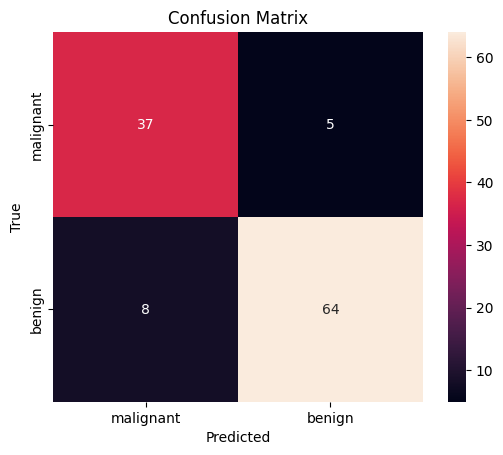

In [ ]:
# Write code here
# ================== Step 6 ==================
def display_classification_report(y_true, y_pred, target_names):
    print("Classification Report:")
    print(classification_report(y_true, y_pred, target_names=target_names))

def display_confusion_matrix(y_true, y_pred):
    mat = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        mat, 
        square=True, 
        annot=True, 
        xticklabels=data.target_names, 
        yticklabels=data.target_names
    )
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')


y_pred = mlp.predict(X_test)
display_classification_report(y_test, y_pred, data.target_names)
display_confusion_matrix(y_test, y_pred)

# ================== Step 7 ==================
hidden_layer_sizes = (
    (100,),
    (50, 50),
    (100, 50, 25)
)
activation_functions = ("tanh", "logistic", "relu")
learning_rates = (0.01, 0.001, 0.0001)

results = []
for hl in hidden_layer_sizes:
    for af in activation_functions:
        for lr in learning_rates:
            mlp = MLPClassifier(
                hidden_layer_sizes=hl,
                activation=af,
                solver='adam',
                learning_rate_init=lr,
                max_iter=5000,
                random_state=42
            )
            mlp.fit(X_train, y_train)
            y_pred = mlp.predict(X_test)
            cf = classification_report(y_test, y_pred, target_names=data.target_names, output_dict=True, zero_division=0)
            results.append({
                "hidden_layer_size": hl,
                "activation_function": af,
                "learning_rate": lr,
                "accuracy": cf['accuracy'],
            })

import pandas as pd
df = pd.DataFrame(results)
df = df.sort_values(by="accuracy", ascending=False)
display(df)



**Answer the following questions**



**1. How does scaling affect MLP performance?** (10 points)




Answer: Normalizing input data is highly influential on MLP performance because 

**2. Compare results between one hidden layer and multiple hidden layers.** (10 points)



Answer:

**3. Plot the loss curve (e.g. mlp.loss_curve_) of the best performing model and describe what you see.** (20 points)



In [15]:
# Write code here

Answer:

Observations:

